In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

# 1. LOAD AND PREPROCESS DATA

In [ ]:


# Load the dataset
file_path = 'Stock mutations type 120 2025(2).csv' 
df = pd.read_csv(file_path)

# Convert 'Datum' to datetime objects
df['Datum'] = pd.to_datetime(df['Datum'], dayfirst=True)


ASSUMPTION: PREDICTING DEMAND (OUTGOING STOCK) <br>
Stock mutations usually contain positive (incoming) and negative (outgoing) values.
To predict "amounts needed", we typically focus on the outgoing stock (Demand).
We filter for negative values and convert them to positive.

In [ ]:
# Ensure 'Aantal' is numeric then drop rows without numeric amounts
df['Aantal'] = pd.to_numeric(df['Aantal'], errors='coerce')
df = df.dropna(subset=['Aantal'])

df_sales = df[df['Aantal'] < 0].copy()
df_sales['Aantal'] = df_sales['Aantal'].abs()

# Aggregate data by Product and Month
# 'MS' = Month Start frequency
monthly_data = df_sales.groupby(['Artikel', pd.Grouper(key='Datum', freq='MS')])['Aantal'].sum().reset_index()

# Pivot data so each column is a product and index is the Date
pivot_df = monthly_data.pivot(index='Datum', columns='Artikel', values='Aantal').fillna(0)

print(f"Data Loaded. Found {pivot_df.shape[1]} unique products.")
print(f"Date Range: {pivot_df.index.min()} to {pivot_df.index.max()}")
print("-" * 30)

Data Loaded. Found 1828 unique products.
Date Range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
------------------------------


# 2. DEFINE TRAINING/VALIDATION/TEST SPLIT

In [ ]:
def get_train_val_test_split(series, test_months=2, val_months=2):
    """
    Splits a time series into Train, Validation, and Test sets.
    - Test: Last `test_months` (2 months)
    - Validation: `val_months` before Test
    - Train: The rest
    """
    n = len(series)
    
    if n < (test_months + val_months + 2):
        return None, None, None # Not enough data
        
    train_end = n - test_months - val_months
    val_end = n - test_months
    
    train = series.iloc[:train_end]
    val = series.iloc[train_end:val_end]
    test = series.iloc[val_end:]
    
    return train, val, test

# 3. TRAIN SARIMA MODEL FUNCTION

In [ ]:
def train_predict_product(product_id, data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    """
    Trains a SARIMA model for a single product and predicts the test period.
    """
    series = data[product_id]
    
    # Split data
    train, val, test = get_train_val_test_split(series)
    
    if train is None:
        print(f"Skipping {product_id}: Not enough data points.")
        return None

    # Combine Train and Val for final Test prediction 
    # Here we fit on Train+Val to predict Test, simulating the 2-month lookahead
    history = pd.concat([train, val])
    
    try:
        # Define and fit the model
        model = SARIMAX(history, order=order, seasonal_order=seasonal_order, 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        
        # Forecast steps = length of test set (2 months)
        forecast = model_fit.forecast(steps=len(test))
        forecast = pd.Series(forecast, index=test.index)
        
        # Calculate Error
        mae = mean_absolute_error(test, forecast)
        
        return {
            'product': product_id,
            'test_actual': test,
            'test_forecast': forecast,
            'mae': mae
        }
    except Exception as e:
        print(f"Error training {product_id}: {e}")
        return None

# 4. RUN MODEL FOR TOP PRODUCTS

Training models for top 5 products...

Processing Product: 0000954700


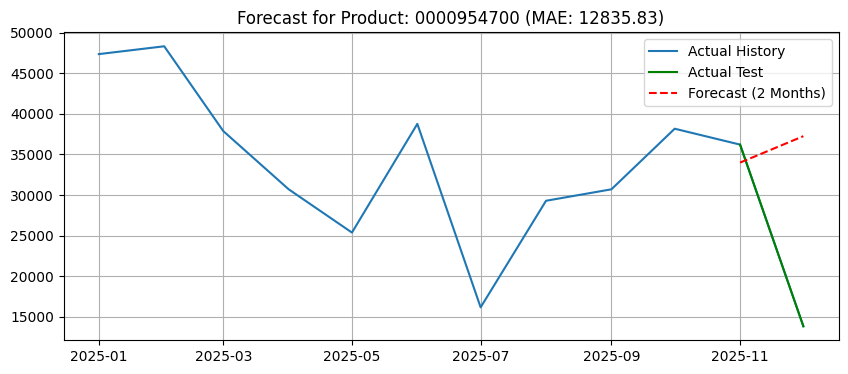

Processing Product: 90000330IN


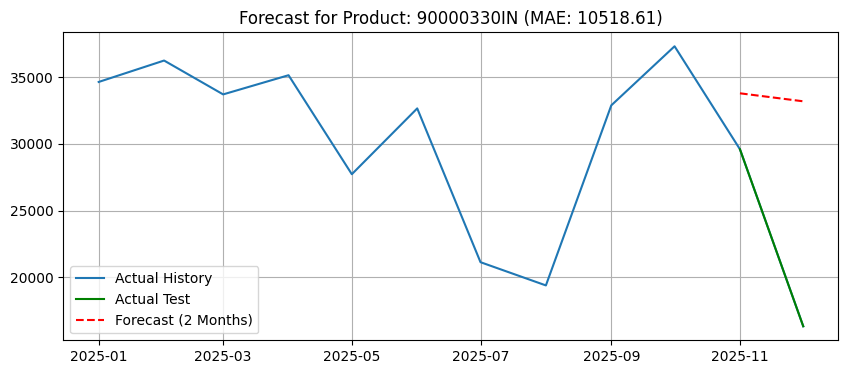

Processing Product: 0000950350


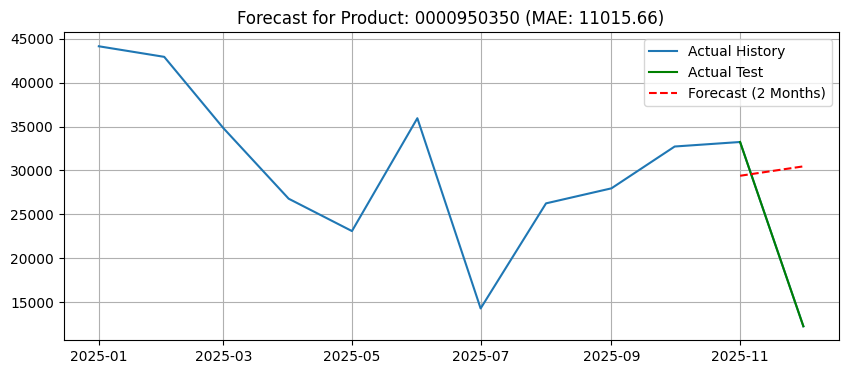

Processing Product: 0000954904


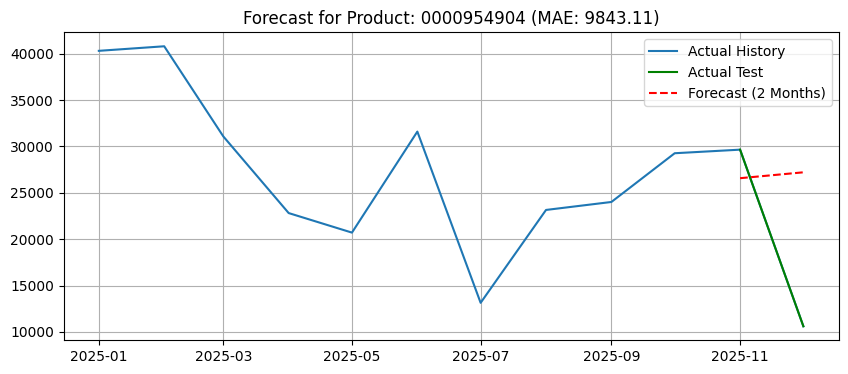

Processing Product: 0000954801


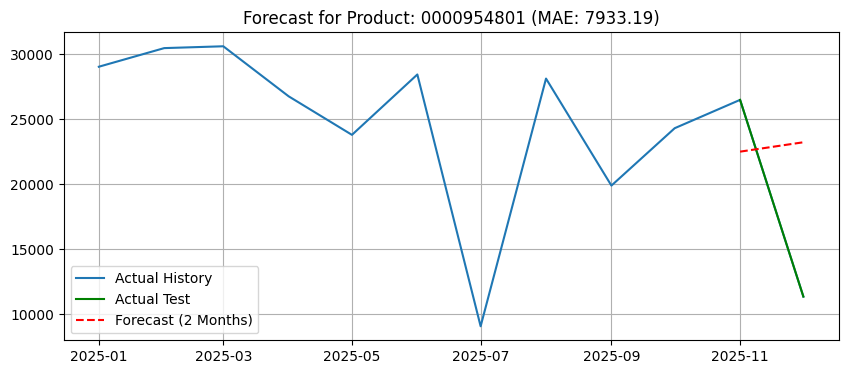

In [ ]:
# Process the top 5 products by volume.
top_products = pivot_df.sum().sort_values(ascending=False).head(5).index.tolist()

results = []

print(f"Training models for top {len(top_products)} products...\n")

for product in top_products:
    print(f"Processing Product: {product}")
    # Using generic ARIMA parameters (1,1,1). 
    res = train_predict_product(product, pivot_df, order=(1,1,1), seasonal_order=(0,0,0,0))
    
    if res:
        results.append(res)
        
        # Visualization
        plt.figure(figsize=(10, 4))
        plt.plot(pivot_df.index, pivot_df[product], label='Actual History')
        plt.plot(res['test_actual'].index, res['test_actual'], label='Actual Test', color='green')
        plt.plot(res['test_forecast'].index, res['test_forecast'], label='Forecast (2 Months)', color='red', linestyle='--')
        plt.title(f"Forecast for Product: {product} (MAE: {res['mae']:.2f})")
        plt.legend()
        plt.grid(True)
        plt.show()

# 5. FUTURE FORECAST (NEXT 2 MONTHS REAL)

In [7]:
print("\n" + "="*30)
print("GENERATING FUTURE FORECASTS (Next 2 Months)")
print("="*30)

future_forecasts = []

# Loop again to predict the unknown future (beyond dataset)
for product in top_products:
    series = pivot_df[product]
    
    try:
        model = SARIMAX(series, order=(1,1,1), seasonal_order=(0,0,0,0), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        
        # Predict next 2 months
        future = model_fit.forecast(steps=2)
        
        future_forecasts.append({
            'Product': product,
            'Month_1': future.iloc[0],
            'Month_2': future.iloc[1]
        })
    except:
        continue

# Display Future Forecast Table
future_df = pd.DataFrame(future_forecasts)
if not future_df.empty:
    print(future_df)
else:
    print("No forecasts generated.")


GENERATING FUTURE FORECASTS (Next 2 Months)
      Product       Month_1       Month_2
0  0000954700  28044.844388  25260.569202
1  90000330IN  24943.596840  25692.750082
2  0000950350  26150.902303  22562.564163
3  0000954904  20876.874845  19208.674128
4  0000954801  27761.330499  19982.853261
